# Ecommerce Sales Data Analysis

In [28]:
!pip install mysql-connector-python==8.0.33

In [29]:
import mysql.connector
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### CONNECT PYTHON TO MYSQL

In [30]:
import mysql.connector
conn = mysql.connector.connect (
    host= 'localhost',
    user= 'root',
    password= '787869',
    database= 'ecommerce sales'
)

cursor = conn.cursor()

### FETCH DATA FROM TABLE

In [31]:
cursor.execute('select * from ecommerce_sales')

data = cursor.fetchall()

### CONVERT TO PANDAS DATAFRAME

In [32]:
import pandas as pd

sales_dataset = pd.DataFrame(data, columns =[col[0] for col in cursor.description])
print('First 5 Rows')
sales_dataset.head()

First 5 Rows


,Order Date,Product Name,Category,Region,Quantity,Sales,Profit
0,2024-12-31,Printer,Office,North,4,3640,348.93
1,2022-11-27,Mouse,Accessories,East,7,1197,106.53
2,2022-05-11,Tablet,Electronics,South,5,5865,502.73
3,2024-03-16,Mouse,Accessories,South,2,786,202.87
4,2022-09-10,Mouse,Accessories,West,1,509,103.28


### UNDERSTAND DATASET

In [33]:
sales_dataset.columns

Index(['Order Date', 'Product Name', 'Category', 'Region', 'Quantity', 'Sales',
       'Profit'],
      dtype='object')

In [34]:
sales_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order Date    3500 non-null   object 
 1   Product Name  3500 non-null   object 
 2   Category      3500 non-null   object 
 3   Region        3500 non-null   object 
 4   Quantity      3500 non-null   int64  
 5   Sales         3500 non-null   int64  
 6   Profit        3500 non-null   float64
dtypes: float64(1), int64(2), object(4)
memory usage: 191.5+ KB


### DATA CLEANING

In [35]:
# Find Null/Missing Value
sales_dataset.isnull().sum()

Order Date      0
Product Name    0
Category        0
Region          0
Quantity        0
Sales           0
Profit          0
dtype: int64

In [36]:
# Find Duplicated Values
sales_dataset.duplicated().sum()

np.int64(0)

### Fix Column Names

In [37]:
sales_dataset.columns = [
    'order_date', 'product_name', 'category',
    'region', 'quantity', 'sales', 'profit'
]

sales_dataset.columns

Index(['order_date', 'product_name', 'category', 'region', 'quantity', 'sales',
       'profit'],
      dtype='object')

In [38]:
sales_dataset.head(2)

,order_date,product_name,category,region,quantity,sales,profit
0,2024-12-31,Printer,Office,North,4,3640,348.93
1,2022-11-27,Mouse,Accessories,East,7,1197,106.53


### Convert Date Column

In [39]:
sales_dataset['order_date'] = pd.to_datetime(sales_dataset['order_date'])

# CORE ANALYSIS

### Total Sales

In [40]:
cursor.execute("select concat(format(sum(sales)/1000000,2),' M') from ecommerce_sales")

data = cursor.fetchall()

for total_sales in data:
    print('\nTotal Sales:')
    print(total_sales)


Total Sales:
('10.67 M',)


### Total Profit

In [41]:
cursor.execute("select concat(format(sum(profit)/100000,2),' L') from ecommerce_sales")

data = cursor.fetchall()

for total_profit in data:
    print('\nTotal Profit:')
    print(total_profit)


Total Profit:
('18.45 L',)


### Sales by Category

In [42]:
cursor.execute("""select category, concat(format(sum(sales)/1000000,2),' M') as sales from ecommerce_sales
                group by category
                order by sales desc """)

data = cursor.fetchall()

print('\nSales by Category:')
for category_sales in data:
    print(category_sales)


Sales by Category:
('Electronics', '5.33 M')
('Accessories', '4.25 M')
('Office', '1.09 M')


### Profit by Category

In [43]:
cursor.execute("""select category, concat(format(sum(profit)/100000,2)," L") as profit from ecommerce_sales
                group by category
                order by profit desc """)

data = cursor.fetchall()

print('\nProfit by Category:')
for category_profit in data:
    print(category_profit)


Profit by Category:
('Electronics', '9.23 L')
('Accessories', '7.36 L')
('Office', '1.85 L')


### Top5 Selling Products

In [44]:
cursor.execute("""select `product name`, concat(format(sum(sales)/1000000,2)," M") as sales from ecommerce_sales
                group by `product name`
                order by sales desc limit 5 """)

data = cursor.fetchall()

print('\nTop 5 Selling Products:')
for Top5 in data:
    print(Top5)


Top 5 Selling Products:
('Camera', '1.18 M')
('Monitor', '1.16 M')
('Printer', '1.09 M')
('Mouse', '1.07 M')
('Smartphone', '1.07 M')


### Region-wise Performance

In [45]:
cursor.execute("""select region, concat(format(sum(sales)/1000000,2)," M") as sales from ecommerce_sales
                group by region
                order by sales desc """)

data = cursor.fetchall()

print('\nRegion-wise Performance:')
for Region in data:
    print(Region)


Region-wise Performance:
('West', '2.84 M')
('East', '2.68 M')
('South', '2.66 M')
('North', '2.49 M')


### Monthly Sales Trend

In [46]:
cursor.execute("""select month(`order date`) as month_no,
date_format(`order date`,"%b") as month_name,
concat(format(sum(sales)/100000,2)," L") as sales from ecommerce_sales
group by month_no, month_name
order by month_no asc""")

data = cursor.fetchall()

print('\nMonthly Sales Trend:')
for trend in data:
    print(trend)


Monthly Sales Trend:
(1, 'Jan', '9.68 L')
(2, 'Feb', '7.02 L')
(3, 'Mar', '9.40 L')
(4, 'Apr', '8.22 L')
(5, 'May', '10.35 L')
(6, 'Jun', '8.40 L')
(7, 'Jul', '8.45 L')
(8, 'Aug', '9.25 L')
(9, 'Sep', '8.86 L')
(10, 'Oct', '8.92 L')
(11, 'Nov', '8.55 L')
(12, 'Dec', '9.59 L')


### Business Insights

In [47]:
print('\nINSIGHTS')

tc = sales_dataset.groupby('category')['sales'].sum().idxmax()
print('Top Caterogy:', tc)

tr = sales_dataset.groupby('region')['sales'].sum().idxmax()
print("Top Region:", tr)

mpp = sales_dataset.groupby('product_name')['profit'].sum().idxmax()
print("Most Profitable Product:", mpp)


INSIGHTS
Top Caterogy: Electronics
Top Region: West
Most Profitable Product: Camera


# Visualization

In [48]:
import matplotlib.pyplot as plt

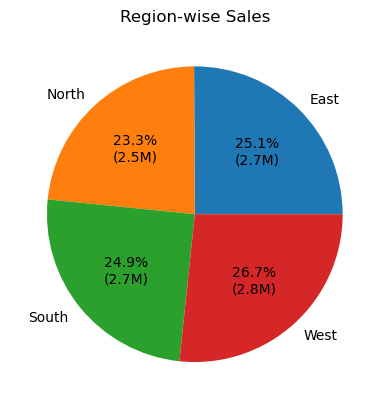

In [49]:
data = sales_dataset.groupby('region')['sales'].sum()

plt.pie(
    data,
    labels=data.index,
    autopct=lambda p: f'{p:.1f}%\n({(p/100)*data.sum()/1_000_000:.1f}M)'
)
    
plt.title('Region-wise Sales')

plt.show()

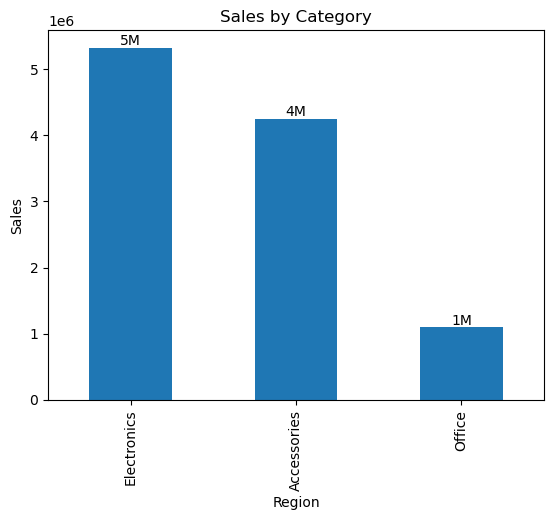

In [50]:
data = sales_dataset.groupby('category')['sales'].sum().sort_values(ascending=False)

x = data.plot(kind='bar')

# Add labels on top of bars
for i, value in enumerate(data):
    x.text(i, value , f"{value/1_000_000:.0f}M", ha='center', va='bottom')
    
plt.title('Sales by Category')
plt.xlabel('Region')
plt.ylabel('Sales')

plt.show()

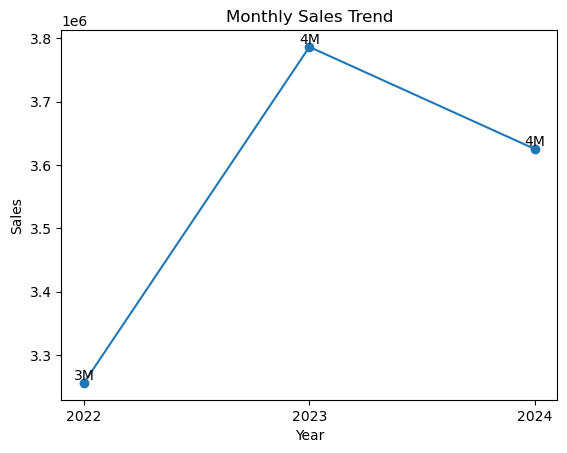

In [51]:
sales_dataset['Year'] = sales_dataset['order_date'].dt.to_period('Y')

data = sales_dataset.groupby('Year')['sales'].sum()

fig, x = plt.subplots()

# Plot line
x.plot(data.index.astype(str), data.values, marker='o')

# Add labels on SAME chart
for i, value in enumerate(data.values):
    x.text(i, value, f"{value/1_000_000:.0f}M", ha='center', va='bottom')

plt.title("Monthly Sales Trend")
plt.xlabel('Year')
plt.ylabel('Sales')

plt.show()

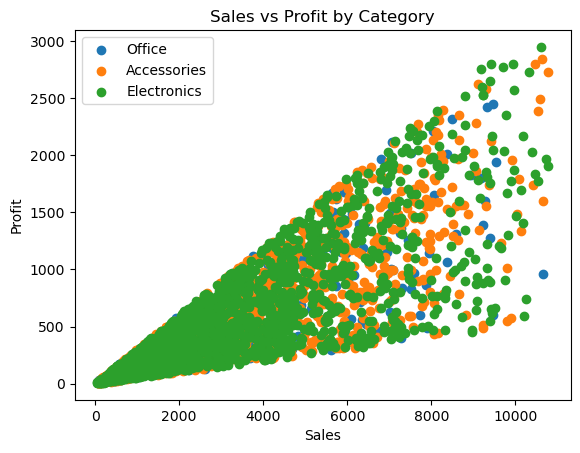

In [52]:
categories = sales_dataset['category'].unique()

for cat in categories:
    subset = sales_dataset[sales_dataset['category'] == cat]
    plt.scatter(subset['sales'], subset['profit'], label=cat)

plt.xlabel("Sales")
plt.ylabel("Profit")
plt.title("Sales vs Profit by Category")

plt.legend()
plt.show()

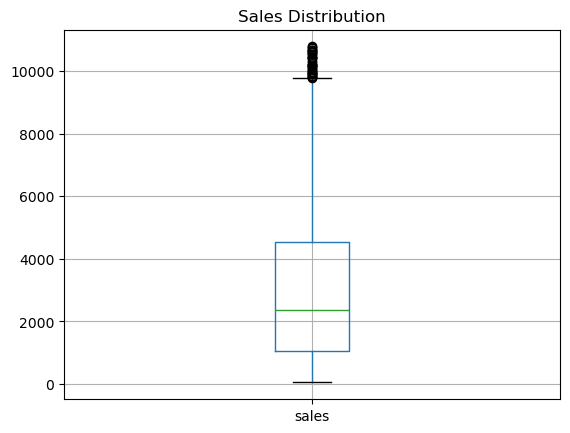

In [53]:
sales_dataset[['sales']].boxplot()
plt.title("Sales Distribution")
plt.show()

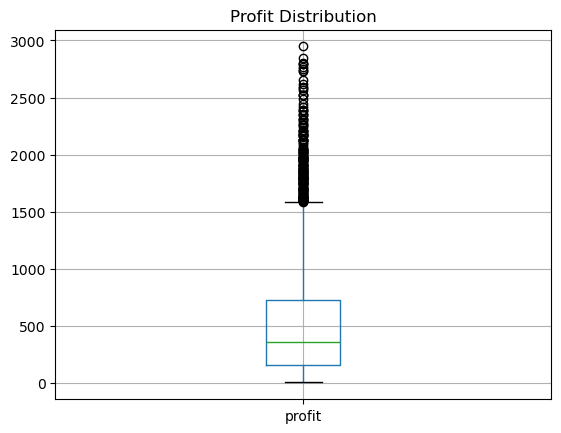

In [139]:
sales_dataset[['profit']].boxplot()
plt.title("Profit Distribution")
plt.show()